In [1]:
from __future__ import annotations

import os
import pickle
import numpy as np

from rtrv_models.gruca3 import GRUCA3
from rtrv_models.data.graph import MazeEnv, maze1_graph, maze2_graph
from rtrv_models.data.preprocess import PreprocessedData, preprocess_data
from rtrv_models.data._io import SAVE_DIR
import torch


DSPPalette = ["#A9CCE3", "#82C3C5", '#9C8FBC', "#D9A6A9", "#DCC8A4", '#647D91', "#C06C84"]

# Just to inspect the observation distributions, same as your CSCG code
maze1 = MazeEnv(maze1_graph)
obs_counts1 = np.histogram(maze1.obs, range=(-0.5, 5.5), bins=6)
print("Maze1 obs counts:", obs_counts1)

maze2 = MazeEnv(maze2_graph)
obs_counts2 = np.histogram(maze2.obs, range=(-0.5, 5.5), bins=6)
print("Maze2 obs counts:", obs_counts2)

mice = [10212, 10224, 10227, 10232]

for mouse in mice:
    print(f"\nProcessing mouse {mouse}")
    save_path_all = os.path.join(SAVE_DIR, f"gruca3_{mouse}.pkl")
    save_path_ego = os.path.join(SAVE_DIR, f"gruca3_{mouse}_ego.pkl")

    if os.path.exists(save_path_all) and os.path.exists(save_path_ego):
        print("  Both models already exist, skip.")
        continue

    res: PreprocessedData = preprocess_data(mouse)

    # -------------------------
    # Common training metadata
    # -------------------------
    beg_train, end_train = res.get_lap_dur_train()
    is_maze1 = res.maze_train[beg_train] == 1

    # Supervised latent-state label = position
    pos = res.pos_train.astype(np.int64)

    # -------------------------
    # 1) Allocentric-action GRU
    # -------------------------
    if not os.path.exists(save_path_all):
        print("  Training allocentric GRU...")

        x_all = res.obs_train.astype(np.int64)
        a_all = res.all_act_train.astype(np.int64)

        # Allocentric actions:
        # 0: North
        # 1: East
        # 2: South
        # 3: West
        # 4: Goal Reached
        n_action_classes_all = 5

        gruca3_all = GRUCA3(
            act=a_all,
            obs=x_all,
            pos=pos,
            n_action_classes=n_action_classes_all,
            # leave n_action_tokens=None so it is inferred automatically
            obs_embed_dim=16,
            act_embed_dim=16,
            hidden_dim=128,
            num_gru_layers=1,
            dropout=0.0,
            predict_next_obs=True,
            lr=1e-3,
            weight_decay=0.0,
            batch_size=32,
            device="cuda" if torch.cuda.is_available() else "cpu",
            pos_loss_weight=1.0,
            act_loss_weight=0.5,
            obs_loss_weight=0.5,
        )

        # Mirror your CSCG training choice: only maze1 laps
        progression_all = gruca3_all.fit_by_trial(
            trial_beg=beg_train[is_maze1],
            trial_end=end_train[is_maze1],
            n_iter=100,
            term_early=False,
        )

        with open(save_path_all, "wb") as f:
            pickle.dump(gruca3_all, f)

        print(f"  Saved allocentric GRU to {save_path_all}")
        print(f"  Final allocentric loss: {progression_all[-1]:.6f}")

    else:
        print("  Allocentric GRU already exists, skip.")

    # -------------------------
    # 2) Egocentric-action GRU
    # -------------------------
    if not os.path.exists(save_path_ego):
        print("  Training egocentric GRU...")

        x_ego = res.obs_train.astype(np.int64)
        a_ego = res.ego_act_train.astype(np.int64)

        # Egocentric actions:
        # 0: Start Moving
        # 1: Left Turn
        # 2: Forward
        # 3: Right Turn
        # 4: Backward
        # 5: Goal Reached
        n_action_classes_ego = 6

        gruca3_ego = GRUCA3(
            act=a_ego,
            obs=x_ego,
            pos=pos,
            n_action_classes=n_action_classes_ego,
            obs_embed_dim=16,
            act_embed_dim=16,
            hidden_dim=128,
            num_gru_layers=1,
            dropout=0.0,
            predict_next_obs=True,
            lr=1e-3,
            weight_decay=0.0,
            batch_size=32,
            device="cuda" if torch.cuda.is_available() else "cpu",
            pos_loss_weight=1.0,
            act_loss_weight=0.5,
            obs_loss_weight=0.5,
        )

        # Mirror your CSCG training choice: use all laps
        progression_ego = gruca3_ego.fit_by_trial(
            trial_beg=beg_train,
            trial_end=end_train,
            n_iter=100,
            term_early=False,
        )

        with open(save_path_ego, "wb") as f:
            pickle.dump(gruca3_ego, f)

        print(f"  Saved egocentric GRU to {save_path_ego}")
        print(f"  Final egocentric loss: {progression_ego[-1]:.6f}")

    else:
        print("  Egocentric GRU already exists, skip.")

Maze1 obs counts: (array([ 1, 17, 35, 74, 16,  1]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]))
Maze2 obs counts: (array([ 1, 19, 34, 71, 18,  1]), array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]))

Processing mouse 10212
  Both models already exist, skip.

Processing mouse 10224
  Both models already exist, skip.

Processing mouse 10227
  Both models already exist, skip.

Processing mouse 10232
  Both models already exist, skip.


100%|██████████| 89/89 [00:00<00:00, 326.17it/s]


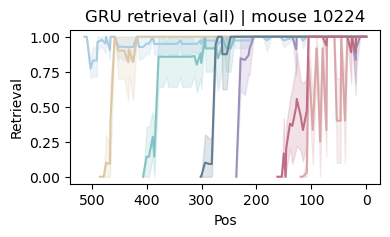

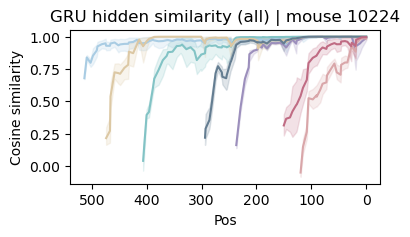

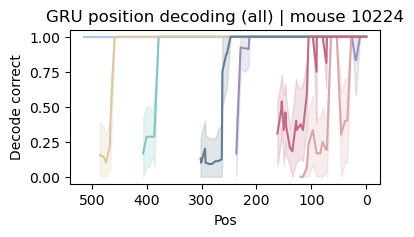

d:\Softwares\Anaconda2025\envs\models\lib\site-packages\torch\nn\modules\rnn.py:1427: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.gru(


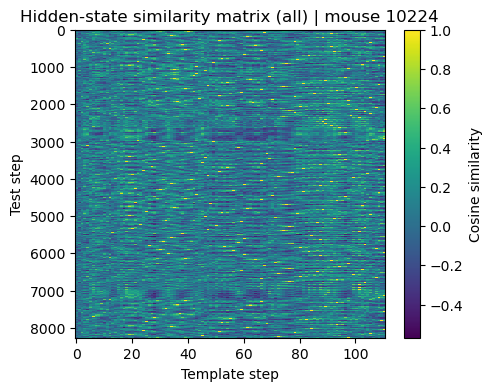

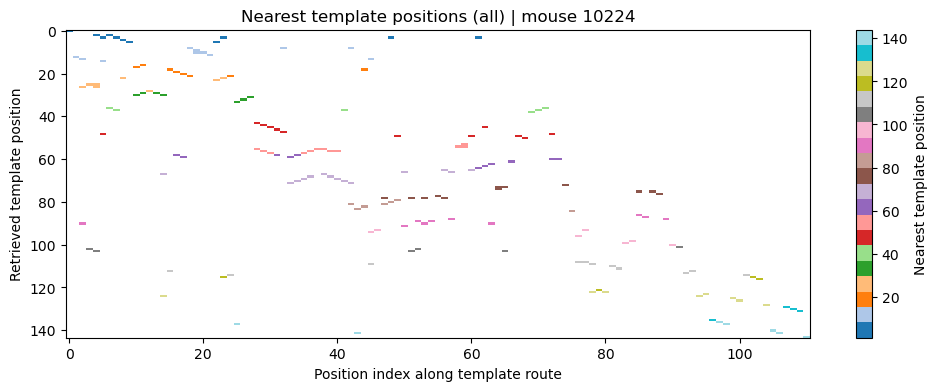

100%|██████████| 89/89 [00:00<00:00, 355.11it/s]


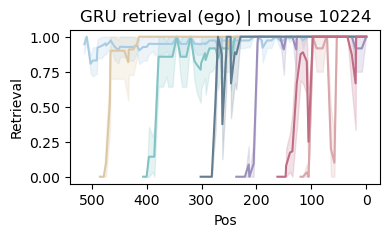

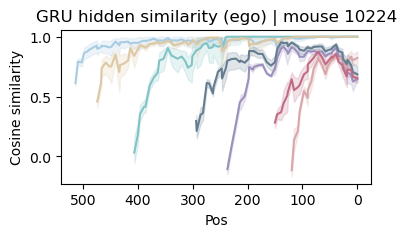

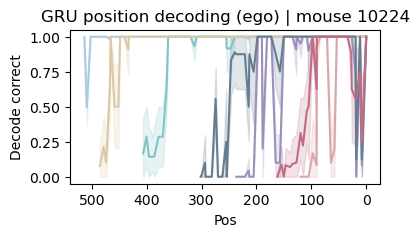

d:\Softwares\Anaconda2025\envs\models\lib\site-packages\torch\nn\modules\rnn.py:1427: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1480.)
  result = _VF.gru(


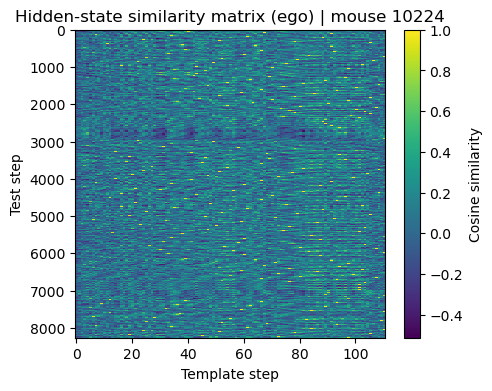

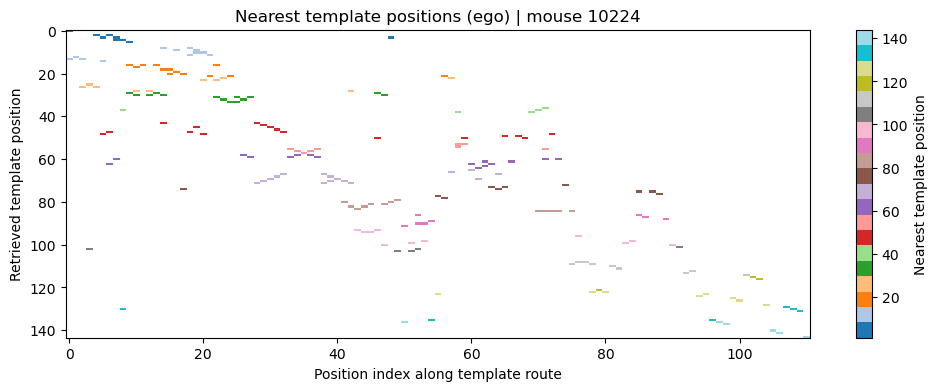

{'hidden_similarity': array([0.68678415, 0.89518258, 0.91400405, ..., 0.99996989, 0.99998147,
        0.99998747], shape=(8107,)),
 'is_retrieval': array([1., 1., 1., ..., 1., 1., 1.], shape=(8107,)),
 'pos_decode_correct': array([1., 0., 1., ..., 1., 1., 1.], shape=(8107,)),
 'Pos': array([513.82485678, 509.50340468, 502.51114828, ...,  11.3137085 ,
          8.        ,   0.        ], shape=(8107,)),
 'Route': array([0., 0., 0., ..., 0., 0., 0.], shape=(8107,))}

In [9]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from tqdm import tqdm

from rtrv_models.data._io import SAVE_DIR
from rtrv_models.data.preprocess import PreprocessedData, preprocess_data
from rtrv_models.data.graph import CP_DSP1, get_metric
from rtrv_models.gruca3 import GRUCA3

DSPPalette = ["#A9CCE3", "#82C3C5", '#9C8FBC', "#D9A6A9", "#DCC8A4", '#647D91', "#C06C84"]


def build_prev_action_tokens(act_seq: np.ndarray, start_action_token: int) -> np.ndarray:
    prev = np.empty_like(act_seq, dtype=np.int64)
    prev[0] = start_action_token
    if len(act_seq) > 1:
        prev[1:] = act_seq[:-1]
    return prev


def get_hidden_and_logits(
    model_wrapper: GRUCA3,
    obs_seq: np.ndarray,
    act_seq: np.ndarray,
):
    """
    Run one sequence through the GRU and return:
    - hidden states: (T, H)
    - position probabilities: (T, 144)
    - predicted positions: (T,) in 1..144
    """
    model_wrapper.model.eval()

    obs_seq = np.asarray(obs_seq, dtype=np.int64)
    act_seq = np.asarray(act_seq, dtype=np.int64)
    prev_act = build_prev_action_tokens(act_seq, model_wrapper.start_action_token)

    obs_tensor = torch.as_tensor(obs_seq[None, :], dtype=torch.long, device=model_wrapper.device)
    prev_act_tensor = torch.as_tensor(prev_act[None, :], dtype=torch.long, device=model_wrapper.device)
    lengths = torch.as_tensor([len(obs_seq)], dtype=torch.long, device=model_wrapper.device)

    with torch.no_grad():
        pos_logits, _, _, h_seq, _ = model_wrapper.model(
            obs_tensor,
            prev_act_tensor,
            lengths=lengths,
            return_hidden=True,
        )

    h_seq = h_seq[0].detach().cpu().numpy()                     # (T, H)
    pos_prob = F.softmax(pos_logits[0], dim=-1).cpu().numpy()  # (T, 144)
    pos_pred = np.argmax(pos_prob, axis=1).astype(np.int64) + 1

    return h_seq, pos_prob, pos_pred


def cosine_similarity_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    a: (T1, H)
    b: (T2, H)
    return: (T1, T2)
    """
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    return a @ b.T


def get_template_seq_with_pos(res: PreprocessedData, rt: int, mode: str = "all"):
    """
    Template route from CP_DSP1 with action/obs/pos.
    """
    pos = CP_DSP1[rt].astype(np.int64)
    obs = res.env.obs[pos - 1].astype(np.int64)

    if mode == "all":
        act = res.env.to_all_actions(pos)
    elif mode == "ego":
        act = res.env.to_ego_actions(pos)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    return act, obs, pos


def map_template_hidden_by_position(
    template_hidden: np.ndarray,
    template_pos: np.ndarray,
):
    """
    Build a 144-length table, where each physical position maps to one template hidden vector.
    Uses the first occurrence in the template.
    """
    hdim = template_hidden.shape[1]
    out = np.full((144, hdim), np.nan, dtype=np.float64)
    seen = set()

    for i, p in enumerate(template_pos):
        if p not in seen:
            out[p - 1] = template_hidden[i]
            seen.add(p)

    return out


def cosine_rowwise(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-8)
    return np.sum(a * b, axis=1)


def nearest_template_position(
    h_test: np.ndarray,
    h_template: np.ndarray,
    pos_template: np.ndarray,
) -> np.ndarray:
    """
    For each test hidden state, find the most similar template hidden state,
    then return its physical position.
    """
    sim = cosine_similarity_matrix(h_test, h_template)  # (T_test, T_template)
    idx = np.argmax(sim, axis=1)
    return pos_template[idx]


def visualize_retrieval_gru(mouse, model: str = "all"):
    """
    Visualize GRU retrieval in a CSCG-like style.

    Outputs
    -------
    data : dict
        Contains:
        - hidden_similarity
        - is_retrieval
        - pos_decode_correct
        - Pos
        - Route
    """
    if model == "all":
        model_file = f"gruca3_{mouse}.pkl"
    elif model == "ego":
        model_file = f"gruca3_{mouse}_ego.pkl"
    else:
        raise ValueError(f"Unknown model type: {model}")

    D1 = get_metric(1)

    with open(os.path.join(SAVE_DIR, model_file), "rb") as f:
        gruca3: GRUCA3 = pickle.load(f)

    res: PreprocessedData = preprocess_data(mouse)

    if model == "all":
        x_test = res.obs_test
        a_test = res.all_act_test
    elif model == "ego":
        x_test = res.obs_test
        a_test = res.ego_act_test

    p_test = res.pos_test
    r_test = res.route_test
    s_test = res.session_test
    
    # Only test on session 0
    idx = np.where(s_test == 0)[0]
    x_test = x_test[idx]
    a_test = a_test[idx]
    p_test = p_test[idx]
    r_test = r_test[idx]
    s_test = s_test[idx]

    # ---------------------------------------------------
    # Template = ideal route 0, analogous to your CSCG code
    # ---------------------------------------------------
    a_perf, x_perf, p_perf = get_template_seq_with_pos(res, rt=0, mode=model)
    h_perf, prob_perf, pos_pred_perf = get_hidden_and_logits(gruca3, x_perf, a_perf)

    # Template hidden state indexed by physical position
    h_perf_by_pos = map_template_hidden_by_position(h_perf, p_perf)

    beg, end = res.get_lap_dur_test()
    lap_idx = np.where(np.isin(beg, idx))[0]
    beg = beg[lap_idx]
    end = end[lap_idx]

    hidden_similarity = np.full(len(x_test), np.nan, dtype=np.float64)
    is_retrieval = np.full(len(x_test), np.nan, dtype=np.float64)
    pos_decode_correct = np.full(len(x_test), np.nan, dtype=np.float64)
    pos_pred_all = np.full(len(x_test), -1, dtype=np.int64)
    template_nearest_pos = np.full(len(x_test), -1, dtype=np.int64)

    for b, e in tqdm(list(zip(beg, end))):
        if s_test[b] != 0:
            continue

        obs_seq = x_test[b:e]
        act_seq = a_test[b:e]
        pos_seq = p_test[b:e]

        h_test, prob_test, pos_pred_test = get_hidden_and_logits(gruca3, obs_seq, act_seq)
        pos_pred_all[b:e] = pos_pred_test

        # ---------------------------------------------------
        # 1) similarity to template hidden state at same position
        # ---------------------------------------------------
        valid = ~np.isnan(h_perf_by_pos[pos_seq - 1]).any(axis=1)
        sim = np.full(len(pos_seq), np.nan, dtype=np.float64)
        if np.any(valid):
            sim[valid] = cosine_rowwise(
                h_test[valid],
                h_perf_by_pos[pos_seq[valid] - 1],
            )
        hidden_similarity[b:e] = sim

        # ---------------------------------------------------
        # 2) discrete retrieval:
        #    nearest template hidden state's position == true position
        # ---------------------------------------------------
        nearest_pos = nearest_template_position(h_test, h_perf, p_perf)
        template_nearest_pos[b:e] = nearest_pos
        is_retrieval[b:e] = (nearest_pos == pos_seq).astype(np.float64)

        # ---------------------------------------------------
        # 3) output decoding correctness
        # ---------------------------------------------------
        pos_decode_correct[b:e] = (pos_pred_test == pos_seq).astype(np.float64)

    # ---------------------------------------------------
    # Use the same position selection logic as your CSCG plot
    # ---------------------------------------------------
    x = D1[p_test - 1, 143]
    idx = np.where(
        (np.isin(p_test, CP_DSP1[0]) & (s_test == 0)) |
        (np.isin(p_test, CP_DSP1[4]) & (r_test == 4) & (s_test == 0)) |
        (np.isin(p_test, CP_DSP1[5]) & (r_test == 5) & (s_test == 0)) |
        (np.isin(p_test, CP_DSP1[6]) & (r_test == 6) & (s_test == 0))
    )[0]

    data = {
        "hidden_similarity": hidden_similarity[idx],
        "is_retrieval": is_retrieval[idx],
        "pos_decode_correct": pos_decode_correct[idx],
        "Pos": x[idx],
        "Route": r_test[idx],
    }

    # ---------------------------------------------------
    # Plot 1: binary retrieval, analogous to CSCG
    # ---------------------------------------------------
    fig = plt.figure(figsize=(4, 2))
    ax = plt.axes()
    sns.lineplot(
        x="Pos",
        y="is_retrieval",
        hue="Route",
        palette=DSPPalette,
        data=data,
        ax=ax,
        legend=False,
    )
    ax.invert_xaxis()
    ax.set_ylabel("Retrieval")
    ax.set_title(f"GRU retrieval ({model}) | mouse {mouse}")
    plt.show()

    # ---------------------------------------------------
    # Plot 2: hidden-state similarity
    # ---------------------------------------------------
    fig = plt.figure(figsize=(4, 2))
    ax = plt.axes()
    sns.lineplot(
        x="Pos",
        y="hidden_similarity",
        hue="Route",
        palette=DSPPalette,
        data=data,
        ax=ax,
        legend=False,
    )
    ax.invert_xaxis()
    ax.set_ylabel("Cosine similarity")
    ax.set_title(f"GRU hidden similarity ({model}) | mouse {mouse}")
    plt.show()

    # ---------------------------------------------------
    # Plot 3: decoded position correctness
    # ---------------------------------------------------
    fig = plt.figure(figsize=(4, 2))
    ax = plt.axes()
    sns.lineplot(
        x="Pos",
        y="pos_decode_correct",
        hue="Route",
        palette=DSPPalette,
        data=data,
        ax=ax,
        legend=False,
    )
    ax.invert_xaxis()
    ax.set_ylabel("Decode correct")
    ax.set_title(f"GRU position decoding ({model}) | mouse {mouse}")
    plt.show()

    # ---------------------------------------------------
    # Plot 4: template similarity matrix for route 0
    # ---------------------------------------------------
    # pick all session-0 route-0 laps
    idx_r0 = np.where((r_test == 0) & (s_test == 0))[0]
    if len(idx_r0) > 0:
        first_idx = idx_r0[0]
        lap_id = res.lap_test[first_idx]
        b0 = np.where(res.lap_test == lap_id)[0][0]
        e0 = np.where(res.lap_test == lap_id)[0][-1] + 1

        h_test0, _, _ = get_hidden_and_logits(gruca3, x_test[b0:e0], a_test[b0:e0])
        sim_mat = cosine_similarity_matrix(h_test0, h_perf)

        plt.figure(figsize=(5, 4))
        plt.imshow(sim_mat, aspect="auto", interpolation="none", cmap="viridis")
        plt.colorbar(label="Cosine similarity")
        plt.xlabel("Template step")
        plt.ylabel("Test step")
        plt.title(f"Hidden-state similarity matrix ({model}) | mouse {mouse}")
        plt.show()

    # ---------------------------------------------------
    # Plot 5: nearest template position
    # ---------------------------------------------------
    popular_pos = []
    for i, bpos in enumerate(CP_DSP1[0]):
        res_idx = np.where((data["Route"] == 0) & (p_test[idx] == bpos) & (s_test[idx] == 0))[0]
        if len(res_idx) == 0:
            popular_pos.append(np.array([], dtype=np.int64))
        else:
            popular_pos.append(np.unique(template_nearest_pos[idx[res_idx]]))

    pop_mat = np.full((144, len(popular_pos)), np.nan)
    for i, pos_set in enumerate(popular_pos):
        if len(pos_set) > 0:
            pop_mat[pos_set - 1, i] = pos_set

    plt.figure(figsize=(12, 4))
    plt.imshow(pop_mat, aspect='auto', cmap='tab20', interpolation='none')
    plt.colorbar(label='Nearest template position')
    plt.xlabel('Position index along template route')
    plt.ylabel('Retrieved template position')
    plt.title(f"Nearest template positions ({model}) | mouse {mouse}")
    plt.show()

    return data

visualize_retrieval_gru(10224, model='all')
visualize_retrieval_gru(10224, model='ego')